In [1]:
import pandas as pd
from datetime import date, timedelta
from fiona.crs import from_epsg
import shapely
import math
import random
import geopandas as gpd
import numpy as np

enc = 'utf-8'
dec = 'greek8'
random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
def create_grid(river_shapes, data_shapes, col_municipal='NAME', col_geometry='geometry', dimension=2):
    """Creates the cell grid for the desired area
    
    Parameters
    --------
    river_shapes : dataframe,
        A GeoDataFrame containing the rivers of the area (to avoid creating cells on them)
                
    data_shapes : dataframe
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities
        
    col_municipal : str, optional
        The column that contains the name for each municipality (default = 'NAME')
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    dimension : int, optional
        The dimension of the square cell in km (eg. 2km x 2km, 1km x 1km) (default = 2)
        
    Returns
    ----------
    cell_df: dataframe
        A dataframe containing the generated cells for each municipality and the centers of each cell
    
    """
    river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
    # Convert cell height dimension to km
    cell_height = (dimension / 6378) * (180 / math.pi)
    
    grid_cells = []
    grid_cells2 = []
    municipal = []
    centers = []
    # Iterate over municipalities to create a grid for each one
    for i in range(data_shapes.shape[0]):
        area_cells = []
        center = []
        # Keep the geometry of municipality
        g_country = data_shapes[col_geometry][i]
        # Extract the bounds of municipality
        xmin, ymin, xmax, ymax = data_shapes[col_geometry][i:i+1].total_bounds
        # Convert cell width dimension to km (dependent to y)
        cell_width  = (dimension / 6378) * (180 / math.pi) / math.cos(ymin  * math.pi/180)
    
        # Iterate to municipality bounds to create the grid's cells
        for x0 in np.arange(xmin, xmax+cell_width, cell_width ):
            for y0 in np.arange(ymin, ymax+cell_height, cell_height):
                y1 = y0+cell_height
                x1 = x0+cell_width
                new_cell = shapely.geometry.box(x0, y0, x1, y1)
                # Check if new cell intersects the municipality
                if new_cell.covered_by(g_country):
                    # Check if new cell intersects previously generated cells
                    delete_cell_boundary = [True for cell in grid_cells2 if new_cell.intersects(cell)]
                    # Check if new cell intersects with rivers
                    delete_cell_river = [True for cell in river_shapes_list if new_cell.intersects(cell)]
                    # Save new cell if it doesn't intersects rivers or previous cells 
                    if not delete_cell_boundary and not delete_cell_river:
                        center.append(new_cell.centroid)
                        area_cells.append(new_cell)
                else:
                    # Continue to next cell generation
                    pass
        # Save the final cells for each municipality
        grid_cells.append(area_cells)
        # Save center of each cell
        centers.append(center)
        # Save municipality name for each generated cell
        municipal.append([data_shapes[col_municipal][i]]*len(area_cells))
        # Save the previous generated cells for intersection check
        grid_cells2 = []
        grid_cells2 = [item for sublist in grid_cells for item in sublist]

    # Flatten lists
    grid_cells_list = [item for sublist in grid_cells for item in sublist]
    centers_list = [item for sublist in centers for item in sublist]
    municipal_list = [item for sublist in municipal for item in sublist]
    
    # Create final GeoDataFrame with municipalities and their cells
    cell_df = gpd.GeoDataFrame(grid_cells_list, columns=[col_geometry], crs=from_epsg(4326))
    cell_df['centers'] = centers_list
    cell_df['NAME'] = municipal_list
    
    x = []
    y = []
    # Extract coordinates from centers
    for index,row in cell_df.iterrows():
        x.append(round(row['centers'].x,5))
        y.append(round(row['centers'].y,5))  
        
    cell_df['x'] = x
    cell_df['y'] = y
    
    return cell_df

def read_river_shapes(col_id, path_rivers, col_geometry='geometry', filter=False, num_region=0, path_region='', *args):
    """Reads rivers shapefile and returns a geopandas dataframe
    
    Parameters
    --------
    col_id : string,
        The name of the column with the id of the river
                
    path_rivers : string
        Path to shapefile of rivers
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    filter : boolean, optional
        If false all rivers will be return (default = False)
        
    num_region : int,optional
        The number of the row of the desired region in GeoDataFrame (default = 0)
        
    path_region : string, optional
        Path to shapefile of region that its' rivers will be kept
        
    data_shapes : dataframe, optional (pass with *args)
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities

    Returns
    ----------
    data: dataframe
        A dataframe containing the desired river shapes
    
    """
    try:
        # reading as shp file
        river_shapes = gpd.read_file(path_rivers, encoding="utf_8")
    except: 
        raise NotImplementedError("Sorry, give me a .shp file.")
    if filter:
        indexes = []
        if path_region:
            try:
                # reading as shp file
                region = gpd.read_file(path_region, encoding="utf_8")
            except: 
                raise NotImplementedError("Sorry, give me a .shp file.")
            for index, row in river_shapes.iterrows():
                if row[col_geometry].intersects(region[col_geometry][num_region]):
                    indexes.append(index)
        else:
            data_shapes=args[0]
            for index, row in river_shapes.iterrows():
                for index2, row2 in data_shapes.iterrows():
                    if row[col_geometry].intersects(row2[col_geometry]):
                        indexes.append(index)
                
        river_shapes = river_shapes.loc[indexes].reset_index(drop=True)
    river_shapes = river_shapes[[col_id, col_geometry]]
    return river_shapes

def process_greek(frame, column):
    frame[column] = frame[column].apply(lambda x : x.strip())
    frame[column] = frame[column].apply(lambda x : x.lower())
    frame[column] = frame[column].apply(lambda x : x.replace('ά','α'))
    frame[column] = frame[column].apply(lambda x : x.replace('έ','ε'))
    frame[column] = frame[column].apply(lambda x : x.replace('ή','η'))
    frame[column] = frame[column].apply(lambda x : x.replace('ί','ι'))
    frame[column] = frame[column].apply(lambda x : x.replace('ύ','υ'))
    frame[column] = frame[column].apply(lambda x : x.replace('ό','ο'))
    frame[column] = frame[column].apply(lambda x : x.replace('ώ','ω'))

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"


greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
thrace_region_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ']
thrace_region_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."


In [7]:
indexes = []

region = thrace_region_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

thrace_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
thrace_gdf.head()

,NAME,KWD_YPES,geometry
0,Αβδήρων,9015,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,Αλεξανδρούπολης,9006,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
2,Αμφίπολης,9049,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."
3,Αρριανών,9019,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
4,Διδυμοτείχου,9007,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."


<AxesSubplot:>

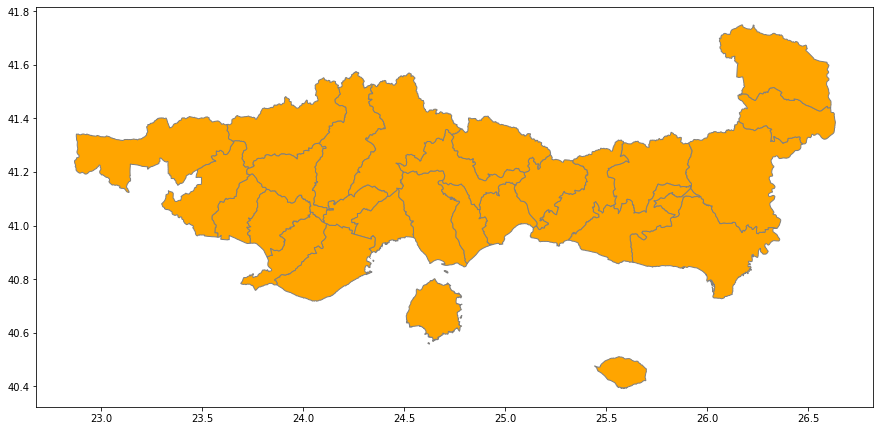

In [9]:
thrace_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
wrong_list = ['Σιντικής' ,'Σερρών', 'Εμμανουήλ Παππά', 'Νέας Ζίχνης', 'Αμφίπολης']

thrace_gdf = thrace_gdf[~thrace_gdf['NAME'].isin(wrong_list)].copy()

In [11]:
thrace_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αβδήρων,9015,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,Αλεξανδρούπολης,9006,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
3,Αρριανών,9019,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
4,Διδυμοτείχου,9007,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."
5,Δοξάτου,9001,"POLYGON ((24.33347 41.14739, 24.33534 41.14657..."


In [12]:
thrace_gdf.drop(columns=['KWD_YPES'], inplace = True)
thrace_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(thrace_gdf, 'lau1')

In [13]:
thrace_gdf.head(5)

,lau1,geometry
0,αβδηρων,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,αλεξανδρουπολης,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
3,αρριανων,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
4,διδυμοτειχου,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."
5,δοξατου,"POLYGON ((24.33347 41.14739, 24.33534 41.14657..."


<AxesSubplot:>

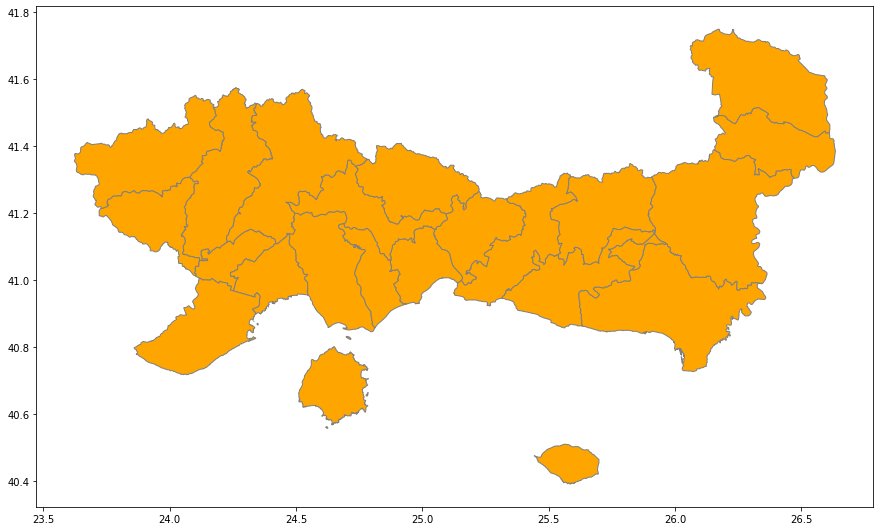

In [14]:
thrace_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
indexes = []

region = thrace_region_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

thrace_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [16]:
thrace_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,1,None,ÑÅÌÁ ÍÉÊÇÔÙÍ,REMA NIKHTVN,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3035.444622,"LINESTRING (25.74206 41.10802, 25.74160 41.107..."
1,2,GR0012000400300270N,ÐËÁÔÕÑÅÌÌÁ Ñ.,PLATYRREMA S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,17558.809512,"LINESTRING (25.75701 41.20519, 25.75759 41.204..."
2,4,None,ÌÁÕÑÏÑÑÅÌÁ,MAYRORREMA,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,6849.963018,"LINESTRING (26.26720 41.07231, 26.26821 41.071..."
3,6,GR0012000400250110N,ËÁÓÐÏÔÏÐÏÓ Ñ.,LASPOPOTAMOS S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4937.957249,"LINESTRING (24.86379 41.04296, 24.86541 41.041..."
4,7,GR001200040B240320N,ÂÁÈÕ Ñ.,VATHY S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,641.106512,"LINESTRING (24.23675 41.49297, 24.23675 41.491..."


<AxesSubplot:>

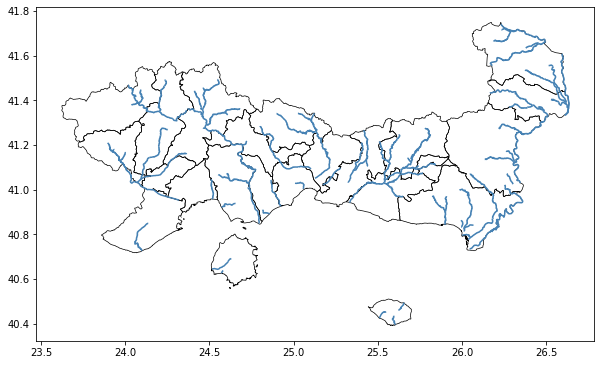

In [17]:
ax = thrace_rivers_gdf.plot(markersize=.1, figsize=(10, 10), cmap='jet', color='steelblue')
thrace_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [18]:
thrace_lau1 = thrace_gdf['lau1'].unique().tolist()

with open('data/GR_SHP_Thrace_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in thrace_lau1:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in Thrace (from shapefile): {len(thrace_lau1)}")

Number of LAU1 Units in Thrace (from shapefile): 22


In [19]:
thrace_gdf.reset_index(inplace=True, drop = True)
thrace_rivers_gdf.reset_index(inplace=True, drop=True)

In [20]:
df_grid = create_grid(thrace_rivers_gdf, thrace_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

C:\Users\dimit\AppData\Local\Temp/ipykernel_28220/2153756921.py:27: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert t

In [21]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

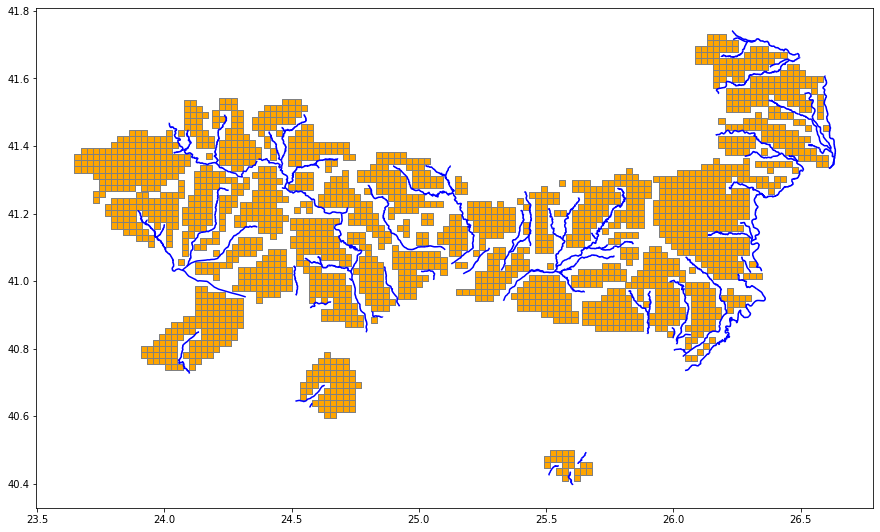

In [22]:
ax = thrace_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [23]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 22


In [24]:
if (len(thrace_lau1) != len(grid_lau1)):
    delta = [item for item in thrace_lau1 if item not in grid_lau1]
    print(delta)

    lost_lau1 = thrace_gdf[thrace_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_thessaly_grid = pd.DataFrame()
    add_to_thessaly_grid['lau1'] = lost_lau1['lau1']
    add_to_thessaly_grid['geometry'] = lost_lau1['geometry']
    add_to_thessaly_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_thessaly_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [25]:
thrace_grid = df_grid.drop(columns=['centers'])

In [26]:
thrace_grid

,geometry,lau1,x,y
0,"POLYGON ((24.91839 41.03638, 24.91839 41.05435...",αβδηρων,24.90650,41.04536
1,"POLYGON ((24.91839 41.05435, 24.91839 41.07231...",αβδηρων,24.90650,41.06333
2,"POLYGON ((24.91839 41.07231, 24.91839 41.09028...",αβδηρων,24.90650,41.08130
3,"POLYGON ((24.91839 41.09028, 24.91839 41.10825...",αβδηρων,24.90650,41.09926
4,"POLYGON ((24.94217 40.94655, 24.94217 40.96451...",αβδηρων,24.93028,40.95553
...,...,...,...,...
2116,"POLYGON ((24.88297 40.91199, 24.88297 40.92995...",τοπειρου,24.87109,40.92097
2117,"POLYGON ((24.88297 40.92995, 24.88297 40.94792...",τοπειρου,24.87109,40.93894
2118,"POLYGON ((24.88297 40.94792, 24.88297 40.96589...",τοπειρου,24.87109,40.95690
2119,"POLYGON ((24.88297 40.96589, 24.88297 40.98385...",τοπειρου,24.87109,40.97487


In [27]:
if (len(thrace_lau1) != len(grid_lau1)):
    thrace_grid = pd.concat([thrace_grid, add_to_thessaly_grid], axis=0)

thrace_grid.reset_index(inplace=True, drop=True)

In [27]:
thrace_grid['nuts3'] = 'ανατολικης μακεδονιας και θρακης'

In [28]:
thrace_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [29]:
thrace_grid

,shape,lau1,x,y,nuts3
0,"POLYGON ((24.91839 41.03638, 24.91839 41.05435...",αβδηρων,24.90650,41.04536,ανατολικης μακεδονιας και θρακης
1,"POLYGON ((24.91839 41.05435, 24.91839 41.07231...",αβδηρων,24.90650,41.06333,ανατολικης μακεδονιας και θρακης
2,"POLYGON ((24.91839 41.07231, 24.91839 41.09028...",αβδηρων,24.90650,41.08130,ανατολικης μακεδονιας και θρακης
3,"POLYGON ((24.91839 41.09028, 24.91839 41.10825...",αβδηρων,24.90650,41.09926,ανατολικης μακεδονιας και θρακης
4,"POLYGON ((24.94217 40.94655, 24.94217 40.96451...",αβδηρων,24.93028,40.95553,ανατολικης μακεδονιας και θρακης
...,...,...,...,...,...
2116,"POLYGON ((24.88297 40.91199, 24.88297 40.92995...",τοπειρου,24.87109,40.92097,ανατολικης μακεδονιας και θρακης
2117,"POLYGON ((24.88297 40.92995, 24.88297 40.94792...",τοπειρου,24.87109,40.93894,ανατολικης μακεδονιας και θρακης
2118,"POLYGON ((24.88297 40.94792, 24.88297 40.96589...",τοπειρου,24.87109,40.95690,ανατολικης μακεδονιας και θρακης
2119,"POLYGON ((24.88297 40.96589, 24.88297 40.98385...",τοπειρου,24.87109,40.97487,ανατολικης μακεδονιας και θρακης


In [30]:
thrace_grid_points = gpd.GeoDataFrame(thrace_grid, geometry=gpd.points_from_xy(thrace_grid.x, thrace_grid.y))

In [31]:
thrace_grid_points

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((24.91839 41.03638, 24.91839 41.05435...",αβδηρων,24.90650,41.04536,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.04536)
1,"POLYGON ((24.91839 41.05435, 24.91839 41.07231...",αβδηρων,24.90650,41.06333,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.06333)
2,"POLYGON ((24.91839 41.07231, 24.91839 41.09028...",αβδηρων,24.90650,41.08130,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.08130)
3,"POLYGON ((24.91839 41.09028, 24.91839 41.10825...",αβδηρων,24.90650,41.09926,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.09926)
4,"POLYGON ((24.94217 40.94655, 24.94217 40.96451...",αβδηρων,24.93028,40.95553,ανατολικης μακεδονιας και θρακης,POINT (24.93028 40.95553)
...,...,...,...,...,...,...
2116,"POLYGON ((24.88297 40.91199, 24.88297 40.92995...",τοπειρου,24.87109,40.92097,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.92097)
2117,"POLYGON ((24.88297 40.92995, 24.88297 40.94792...",τοπειρου,24.87109,40.93894,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.93894)
2118,"POLYGON ((24.88297 40.94792, 24.88297 40.96589...",τοπειρου,24.87109,40.95690,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.95690)
2119,"POLYGON ((24.88297 40.96589, 24.88297 40.98385...",τοπειρου,24.87109,40.97487,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.97487)


<AxesSubplot:>

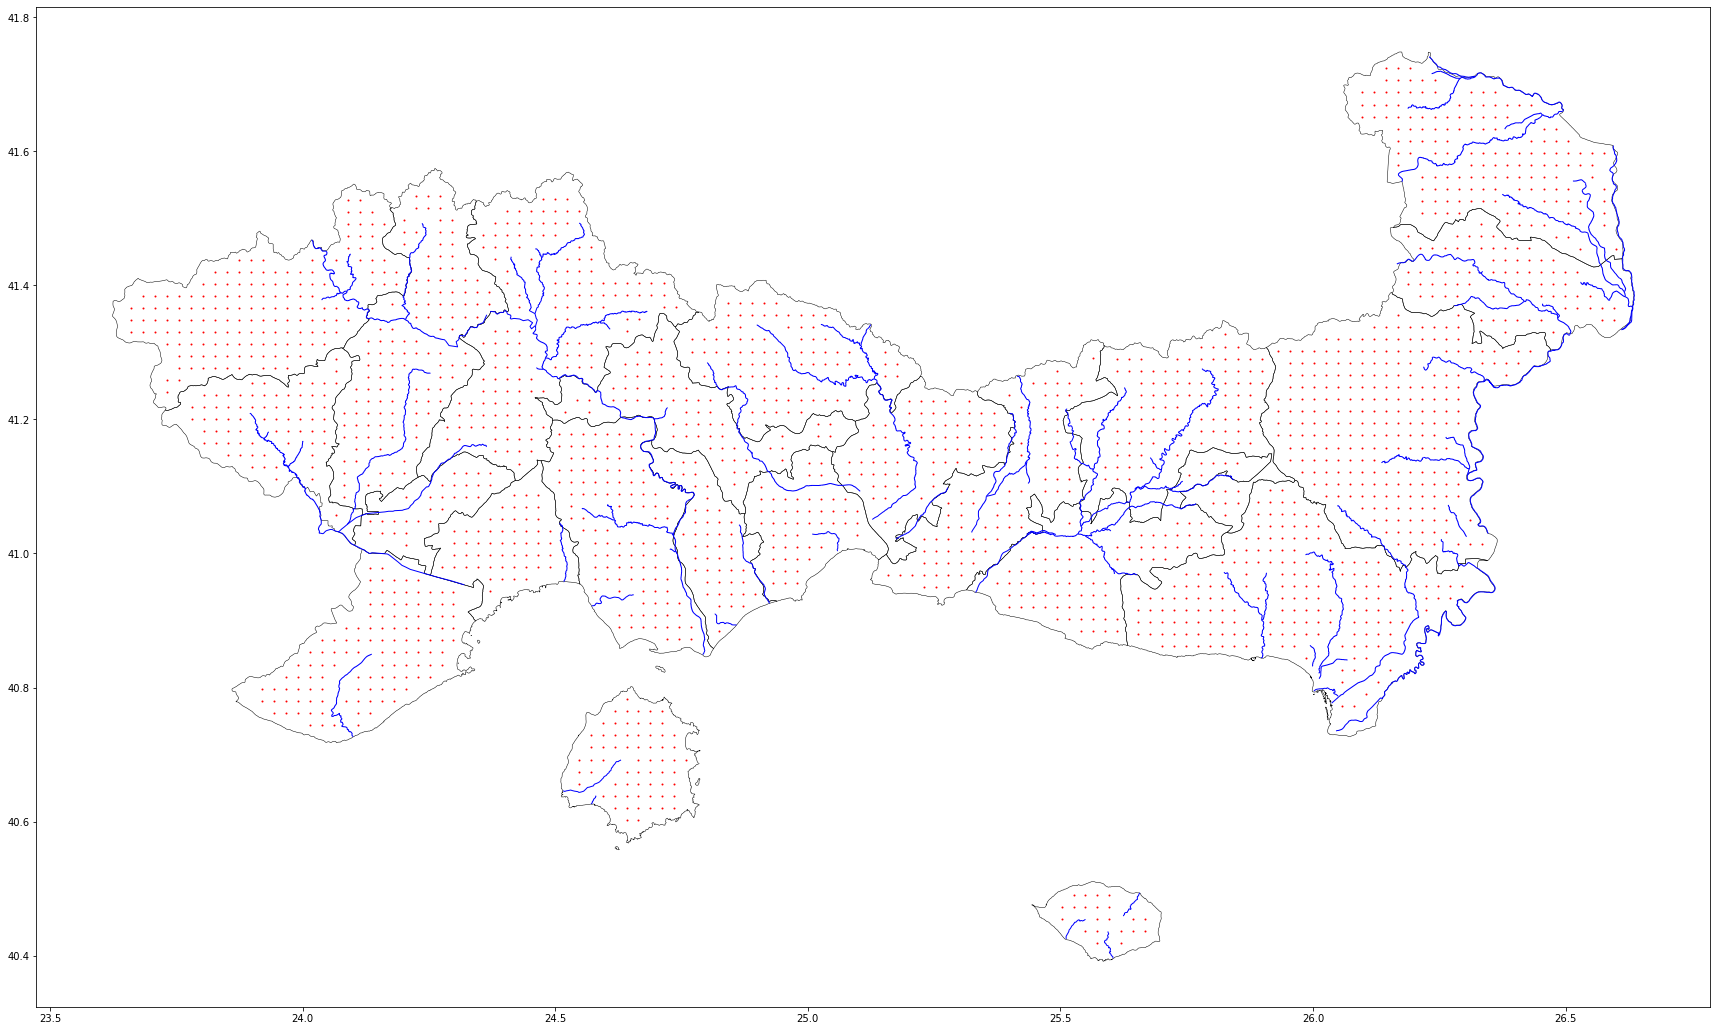

In [32]:
ax = thrace_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
thrace_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
thrace_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [33]:
value_counts = thrace_grid['lau1'].value_counts().sort_values()

In [34]:
arr = value_counts.values

In [35]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [36]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [37]:
value_counts_target

σαμοθρακης            1
δοξατου               1
τοπειρου              2
αβδηρων               3
καβαλας               3
ξανθης                3
θασου                 4
ιασμου                4
προσοτσανης           4
διδυμοτειχου          4
κομοτηνης             5
μυκης                 5
μαρωνειας - σαπων     5
αρριανων              6
νεστου                7
παγγαιου              7
δραμας                8
παρανεστιου           9
ορεστιαδας            9
κατω νευροκοπιου     10
αλεξανδρουπολης      12
σουφλιου             16
dtype: int32

In [38]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: σαμοθρακης || Value: 21 || Target Value: 1
Index: δοξατου || Value: 28 || Target Value: 1
Index: τοπειρου || Value: 47 || Target Value: 2
Index: αβδηρων || Value: 50 || Target Value: 3
Index: καβαλας || Value: 54 || Target Value: 3
Index: ξανθης || Value: 63 || Target Value: 3
Index: θασου || Value: 65 || Target Value: 4
Index: ιασμου || Value: 67 || Target Value: 4
Index: προσοτσανης || Value: 71 || Target Value: 4
Index: διδυμοτειχου || Value: 72 || Target Value: 4
Index: κομοτηνης || Value: 82 || Target Value: 5
Index: μυκης || Value: 84 || Target Value: 5
Index: μαρωνειας - σαπων || Value: 90 || Target Value: 5
Index: αρριανων || Value: 104 || Target Value: 6
Index: νεστου || Value: 109 || Target Value: 7
Index: παγγαιου || Value: 118 || Target Value: 7
Index: δραμας || Value: 127 || Target Value: 8
Index: παρανεστιου || Value: 143 || Target Value: 9
Index: ορεστιαδας || Value: 146 || Target Value: 9
Index: κατω νευροκοπιου || Value: 157 || Target Value: 10
Index: αλεξανδρου

In [39]:
to_remove = pd.Series(data=points, index=idx)

In [40]:
to_remove

σαμοθρακης            20
δοξατου               27
τοπειρου              45
αβδηρων               47
καβαλας               51
ξανθης                60
θασου                 61
ιασμου                63
προσοτσανης           67
διδυμοτειχου          68
κομοτηνης             77
μυκης                 79
μαρωνειας - σαπων     85
αρριανων              98
νεστου               102
παγγαιου             111
δραμας               119
παρανεστιου          134
ορεστιαδας           137
κατω νευροκοπιου     147
αλεξανδρουπολης      172
σουφλιου             223
dtype: int64

In [41]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = thrace_grid.loc[thrace_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

thrace_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
thrace_grid.reset_index(inplace = True, drop = True)

In [42]:
thrace_grid_points = gpd.GeoDataFrame(thrace_grid, geometry=gpd.points_from_xy(thrace_grid.x, thrace_grid.y))

<AxesSubplot:>

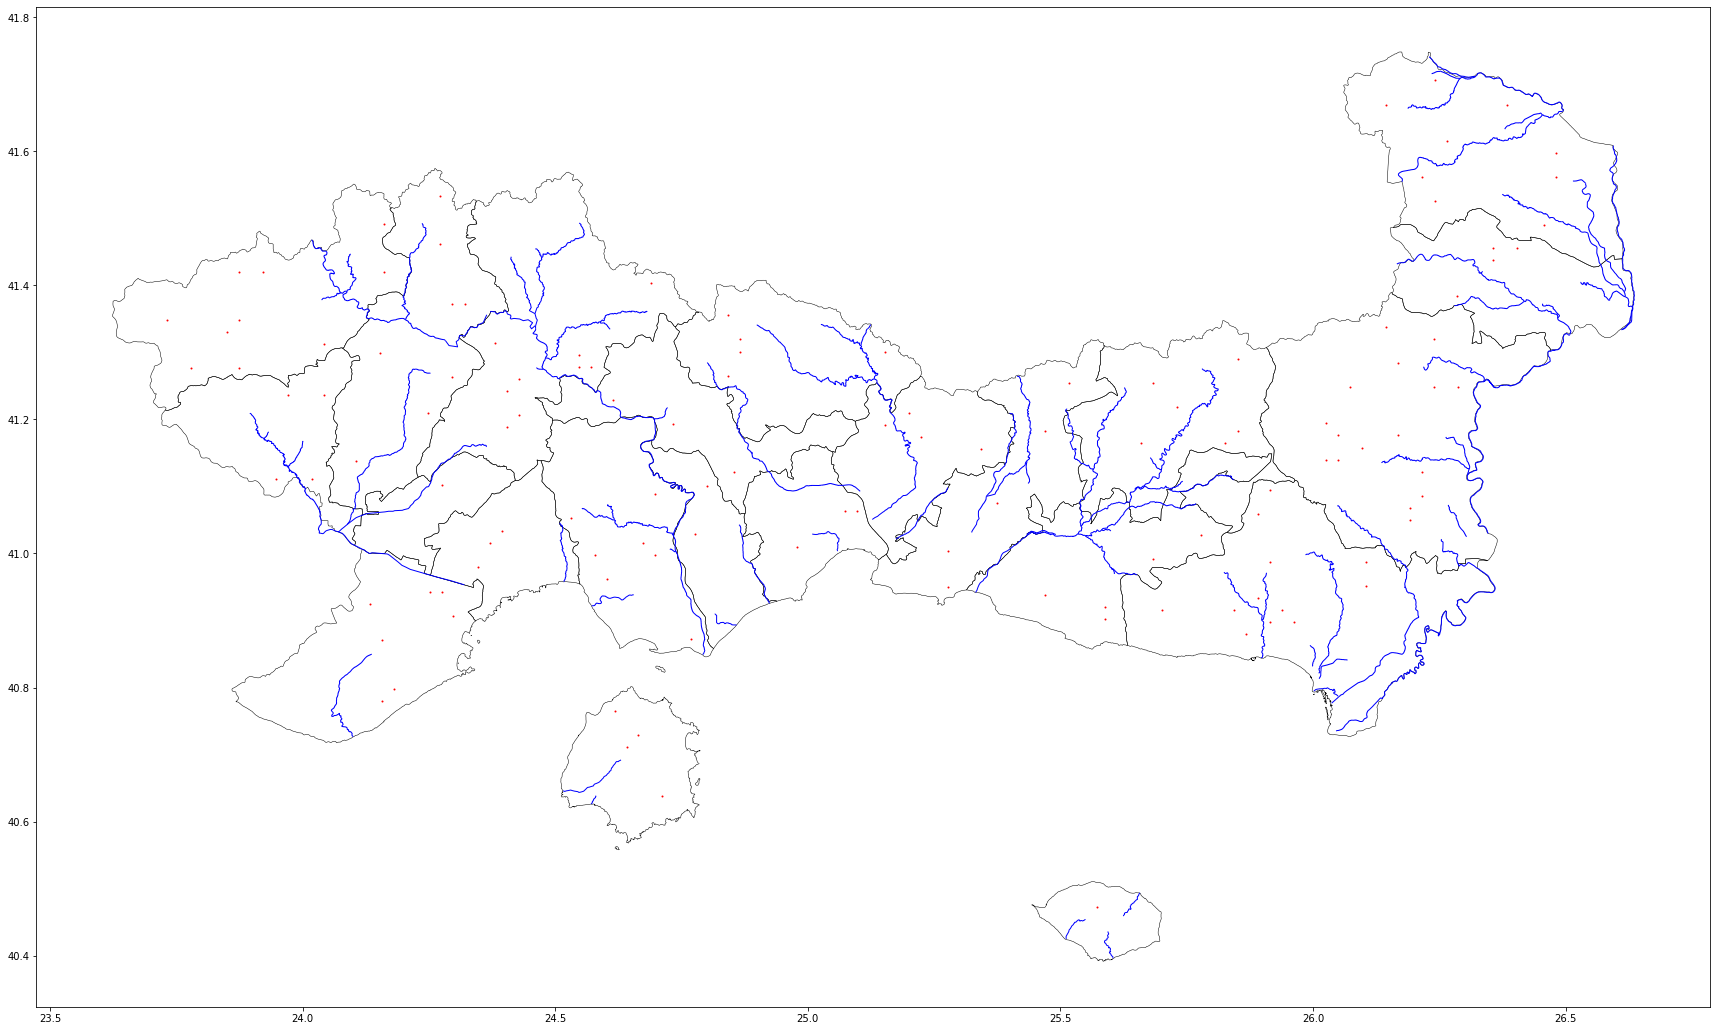

In [43]:
ax = thrace_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
thrace_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
thrace_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [44]:
len(thrace_grid['lau1'].unique())

22

In [45]:
thrace_grid

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((24.98973 41.00045, 24.98973 41.01841...",αβδηρων,24.97784,41.00943,ανατολικης μακεδονιας και θρακης,POINT (24.97784 41.00943)
1,"POLYGON ((25.08485 41.05435, 25.08485 41.07231...",αβδηρων,25.07296,41.06333,ανατολικης μακεδονιας και θρακης,POINT (25.07296 41.06333)
2,"POLYGON ((25.10863 41.05435, 25.10863 41.07231...",αβδηρων,25.09674,41.06333,ανατολικης μακεδονιας και θρακης,POINT (25.09674 41.06333)
3,"POLYGON ((25.71373 40.90646, 25.71373 40.92443...",αλεξανδρουπολης,25.70187,40.91545,ανατολικης μακεδονιας και θρακης,POINT (25.70187 40.91545)
4,"POLYGON ((25.85598 40.90646, 25.85598 40.92443...",αλεξανδρουπολης,25.84412,40.91545,ανατολικης μακεδονιας και θρακης,POINT (25.84412 40.91545)
...,...,...,...,...,...,...
123,"POLYGON ((26.25095 41.23903, 26.25095 41.25700...",σουφλιου,26.23905,41.24801,ανατολικης μακεδονιας και θρακης,POINT (26.23905 41.24801)
124,"POLYGON ((26.25095 41.31090, 26.25095 41.32886...",σουφλιου,26.23905,41.31988,ανατολικης μακεδονιας και θρακης,POINT (26.23905 41.31988)
125,"POLYGON ((26.29854 41.23903, 26.29854 41.25700...",σουφλιου,26.28664,41.24801,ανατολικης μακεδονιας και θρακης,POINT (26.28664 41.24801)
126,"POLYGON ((24.78795 41.01979, 24.78795 41.03775...",τοπειρου,24.77607,41.02877,ανατολικης μακεδονιας και θρακης,POINT (24.77607 41.02877)


In [46]:
start = start_dt = date(2010, 1, 1)
end = end_dt = date(2021, 12, 31)
delta = timedelta(days=1)

In [47]:
dates = []

while start_dt <= end_dt:
    dates.append(start_dt.isoformat())
    start_dt += delta

In [48]:
print('Dates between', start, 'and', end)
print(dates)

Dates between 2010-01-01 and 2021-12-31
['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08', '2010-01-09', '2010-01-10', '2010-01-11', '2010-01-12', '2010-01-13', '2010-01-14', '2010-01-15', '2010-01-16', '2010-01-17', '2010-01-18', '2010-01-19', '2010-01-20', '2010-01-21', '2010-01-22', '2010-01-23', '2010-01-24', '2010-01-25', '2010-01-26', '2010-01-27', '2010-01-28', '2010-01-29', '2010-01-30', '2010-01-31', '2010-02-01', '2010-02-02', '2010-02-03', '2010-02-04', '2010-02-05', '2010-02-06', '2010-02-07', '2010-02-08', '2010-02-09', '2010-02-10', '2010-02-11', '2010-02-12', '2010-02-13', '2010-02-14', '2010-02-15', '2010-02-16', '2010-02-17', '2010-02-18', '2010-02-19', '2010-02-20', '2010-02-21', '2010-02-22', '2010-02-23', '2010-02-24', '2010-02-25', '2010-02-26', '2010-02-27', '2010-02-28', '2010-03-01', '2010-03-02', '2010-03-03', '2010-03-04', '2010-03-05', '2010-03-06', '2010-03-07', '2010-03-08', '2010-03-09', '2010-0

In [49]:
len(dates)

4383

In [50]:
thrace_timeline = pd.DataFrame()

In [51]:
for index, row in thrace_grid.iterrows():
    for date in dates:
        thrace_timeline = thrace_timeline.append({'lau1' : row['lau1'], 
                                                  'region' : row['nuts3'], 
                                                  'x' : row['x'],
                                                  'y' : row['y'],
                                                  'dt_placement': date}, 
                                                  ignore_index = True)

In [52]:
thrace_timeline

,lau1,region,x,y,dt_placement
0,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-01
1,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-02
2,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-03
3,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-04
4,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-05
...,...,...,...,...,...
561019,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-27
561020,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-28
561021,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-29
561022,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-30


In [53]:
thrace_timeline['dt_placement'] = pd.to_datetime(thrace_timeline['dt_placement'])

In [54]:
thrace_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561024 entries, 0 to 561023
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   lau1          561024 non-null  object        
 1   region        561024 non-null  object        
 2   x             561024 non-null  float64       
 3   y             561024 non-null  float64       
 4   dt_placement  561024 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 21.4+ MB


In [55]:
thrace_timeline.to_csv('data/GR_Thrace_Spatiotemporal_Timeline_2010-2021.csv', index = False)

In [56]:
thrace_timeline

,lau1,region,x,y,dt_placement
0,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-01
1,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-02
2,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-03
3,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-04
4,αβδηρων,ανατολικης μακεδονιας και θρακης,24.97784,41.00943,2010-01-05
...,...,...,...,...,...
561019,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-27
561020,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-28
561021,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-29
561022,τοπειρου,ανατολικης μακεδονιας και θρακης,24.79983,41.10064,2021-12-30


In [57]:
thrace_timeline['dt_placement'].iloc[15].day

16

In [58]:
thrace_timeline_biweekly = thrace_timeline.copy()
remove = []

for index, row in thrace_timeline.iterrows():
    if row['dt_placement'].day == 1 or row['dt_placement'].day == 16:
        pass
    else:
        remove.append(index)


thrace_timeline_biweekly.drop(index = remove, axis = 1, inplace = True)
thrace_timeline_biweekly.reset_index(inplace = True, drop = True)

In [59]:
thrace_timeline_biweekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36864 entries, 0 to 36863
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   lau1          36864 non-null  object        
 1   region        36864 non-null  object        
 2   x             36864 non-null  float64       
 3   y             36864 non-null  float64       
 4   dt_placement  36864 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 1.4+ MB


In [60]:
thrace_timeline_biweekly.to_csv('data/GR_Thrace_Spatiotemporal_Timeline_Biweekly_2010-2021.csv', index = False)